Dataset Loaded Successfully
Dataset Shape: (200, 4)

First 5 Rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.2838

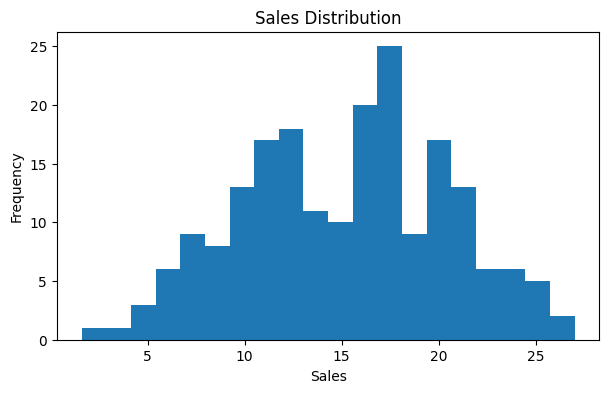

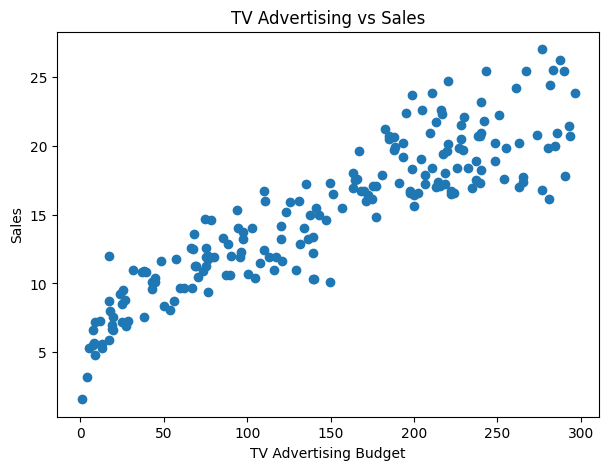

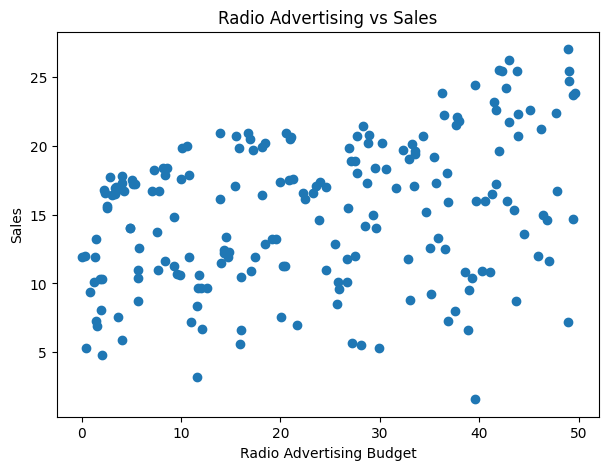

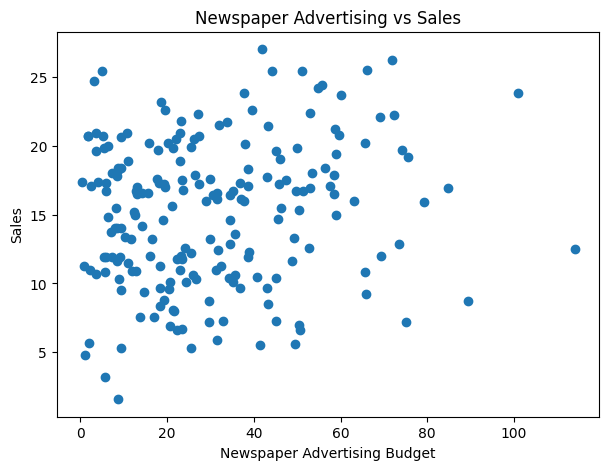

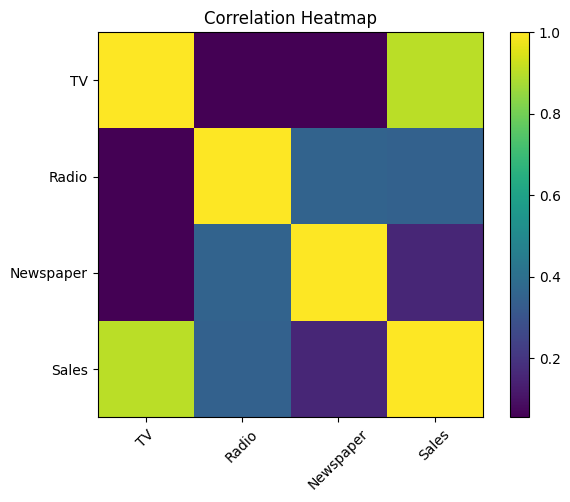


Correlation with Sales:
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)

Linear Regression
R2 Score: 0.9059
MAE: 1.2748
MSE: 2.9078
RMSE: 1.7052
Cross Validation R2: 0.8954

Ridge Regression
R2 Score: 0.9057
MAE: 1.2734
MSE: 2.9153
RMSE: 1.7074
Cross Validation R2: 0.8954

Lasso Regression
R2 Score: 0.9059
MAE: 1.2725
MSE: 2.9071
RMSE: 1.705
Cross Validation R2: 0.8955

Random Forest Regressor
R2 Score: 0.9535
MAE: 0.918
MSE: 1.4374
RMSE: 1.1989
Cross Validation R2: 0.9417

Gradient Boosting Regressor
R2 Score: 0.9594
MAE: 0.8301
MSE: 1.2553
RMSE: 1.1204
Cross Validation R2: 0.9386

Model Comparison:
                         Model  R2 Score       MAE       MSE      RMSE  \
0            Linear Regression  0.905901  1.274826  2.907757  1.705215   
1             Ridge Regression  0.905656  1.273447  2.915318  1.707430   
2             Lasso Regression  0.905922  

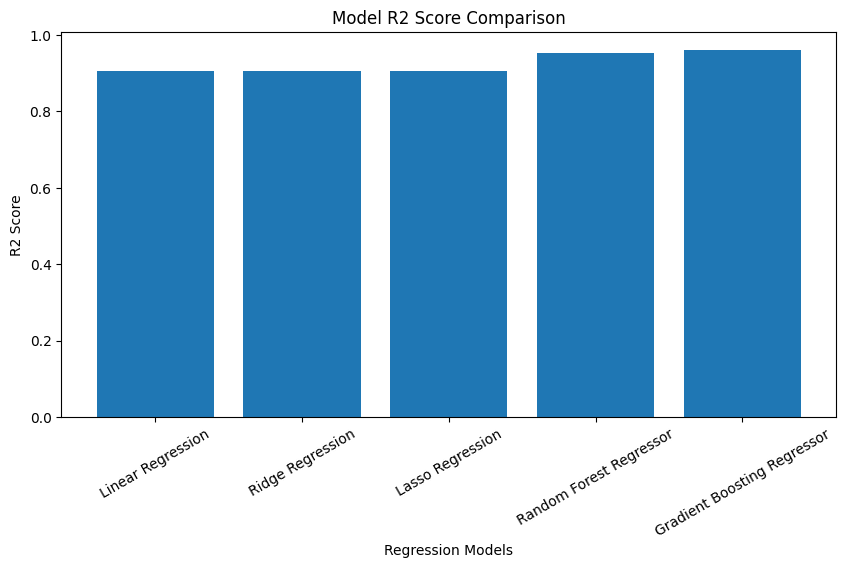

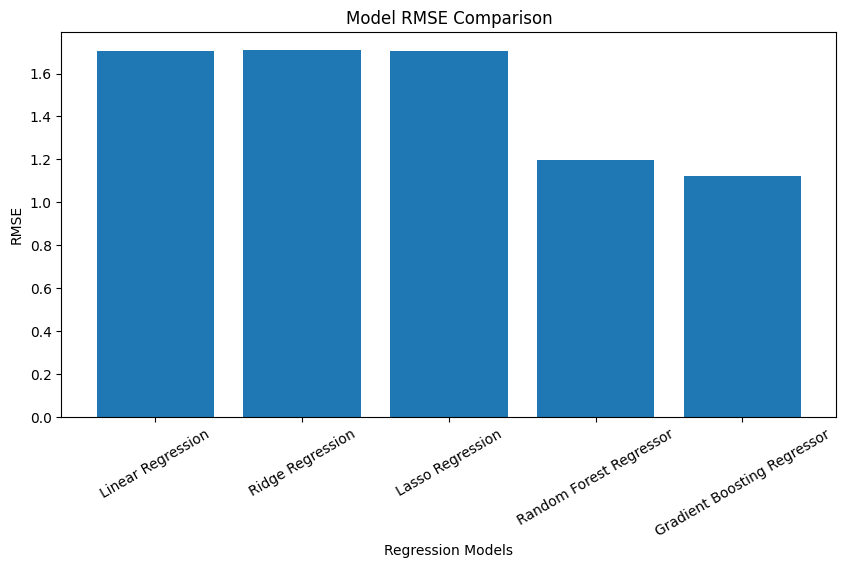


Best Performing Model: Gradient Boosting Regressor

Final Model Performance:
R2 Score: 0.9594
MAE: 0.8301
RMSE: 1.1204

Actual vs Predicted Sales:
   Actual Sales  Predicted Sales
0          16.9        17.418853
1          22.4        23.212464
2          21.4        20.330857
3           7.3         6.198881
4          24.7        23.764753
5          12.6        13.672833
6          22.3        22.424404
7           8.4         9.639888
8          16.5        16.718710
9          16.1        16.080100


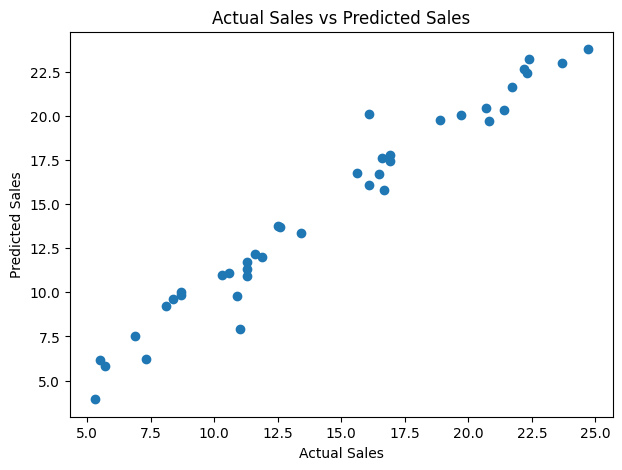


Feature Importance:
     Feature  Importance
0         TV    0.852783
1      Radio    0.135441
2  Newspaper    0.011776


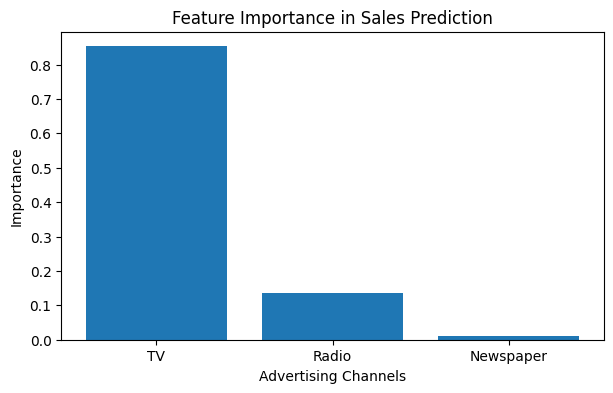


Business Insight:
TV advertising has the highest impact on sales prediction.

New Advertising Budget:
    TV  Radio  Newspaper
0  200     40         50

Predicted Sales: 20.46


In [1]:
# CODSOFT Data Science Internship
# Task 4: Sales Prediction Using Python - Advanced Professional Version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load Dataset
df = pd.read_csv("advertising.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# 2. Remove Unnecessary Index Column if Present
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

print("\nFinal Columns:")
print(df.columns)

# 3. Sales Distribution
plt.figure(figsize=(7,4))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# 4. TV vs Sales
plt.figure(figsize=(7,5))
plt.scatter(df["TV"], df["Sales"])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()

# 5. Radio vs Sales
plt.figure(figsize=(7,5))
plt.scatter(df["Radio"], df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.show()

# 6. Newspaper vs Sales
plt.figure(figsize=(7,5))
plt.scatter(df["Newspaper"], df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.show()

# 7. Correlation Heatmap
corr = df.corr()

plt.figure(figsize=(7,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with Sales:")
print(corr["Sales"].sort_values(ascending=False))

# 8. Features and Target
X = df.drop("Sales", axis=1)
y = df["Sales"]

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# 10. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 11. Regression Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():

    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_score = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring="r2").mean()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_score = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Cross Validation R2": cv_score
    })

    print("\n====================================")
    print(name)
    print("====================================")
    print("R2 Score:", round(r2, 4))
    print("MAE:", round(mae, 4))
    print("MSE:", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("Cross Validation R2:", round(cv_score, 4))

# 12. Model Comparison Table
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# 13. R2 Score Comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model R2 Score Comparison")
plt.xlabel("Regression Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

# 14. RMSE Comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model RMSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

# 15. Select Best Model
best_model_name = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]["Model"]
print("\nBest Performing Model:", best_model_name)

# 16. Final Model
final_model = GradientBoostingRegressor(random_state=42)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("\nFinal Model Performance:")
print("R2 Score:", round(r2_score(y_test, final_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, final_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, final_pred)), 4))

# 17. Actual vs Predicted Sales
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": final_pred
})

print("\nActual vs Predicted Sales:")
print(comparison.head(10))

plt.figure(figsize=(7,5))
plt.scatter(y_test, final_pred)
plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

# 18. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(7,4))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance in Sales Prediction")
plt.xlabel("Advertising Channels")
plt.ylabel("Importance")
plt.show()

# 19. Business Insight
print("\nBusiness Insight:")
top_feature = importance.iloc[0]["Feature"]
print(f"{top_feature} advertising has the highest impact on sales prediction.")

# 20. Future Sales Prediction
new_budget = pd.DataFrame({
    "TV": [200],
    "Radio": [40],
    "Newspaper": [50]
})

predicted_sales = final_model.predict(new_budget)

print("\nNew Advertising Budget:")
print(new_budget)

print("\nPredicted Sales:", round(predicted_sales[0], 2))